# 01 - Data Exploration

Speech Emotion Recognition project - first pass at understanding the dataset
before doing any feature engineering.

**Dataset used:** [RAVDESS](https://zenodo.org/record/1188976) (Ryerson Audio-Visual
Database of Emotional Speech and Song). You can swap this out for TESS or CREMA-D
with minor changes to the filename-parsing logic below.

Download the RAVDESS "Audio_Speech_Actors_01-24.zip" and extract it into
`../data/RAVDESS/` before running this notebook, so the folder looks like:

```
data/RAVDESS/Actor_01/03-01-01-01-01-01-01.wav
data/RAVDESS/Actor_02/...
...
```


In [28]:
import io
import zipfile
from pathlib import Path

import fsspec
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import soundfile as sf

try:
    import librosa
except Exception as exc:
    librosa = None
    print(
        f"librosa unavailable ({exc}). Audio reading will use soundfile; "
        "the mel-spectrogram cells will be skipped until a compatible librosa/soxr install is present."
    )

DATA_DIR = (Path.cwd().parent / "data" / "RAVDESS").resolve()
DATASET_URL = "https://zenodo.org/record/1188976/files/Audio_Speech_Actors_01-24.zip"

# Lazy, seekable handle to the remote zip. Reads happen via HTTP range
# requests on demand, so the ~25GB archive is never downloaded/extracted
# to disk - only the bytes of the file currently being processed.
remote_zip_file = fsspec.open(DATASET_URL, mode="rb").open()
zf = zipfile.ZipFile(remote_zip_file)

wav_names = [n for n in zf.namelist() if n.lower().endswith(".wav")]
print(f"Found {len(wav_names)} audio files in the remote archive (nothing downloaded yet).")


Found 1440 audio files in the remote archive (nothing downloaded yet).


## RAVDESS filename convention

Each file is named like `03-01-06-01-02-01-12.wav`. The third number is the
emotion code:

| Code | Emotion   |
|------|-----------|
| 01   | neutral   |
| 02   | calm      |
| 03   | happy     |
| 04   | sad       |
| 05   | angry     |
| 06   | fearful   |
| 07   | disgust   |
| 08   | surprised |


In [29]:

EMOTION_MAP = {
    "01": "neutral", "02": "calm", "03": "happy", "04": "sad",
    "05": "angry", "06": "fearful", "07": "disgust", "08": "surprised",
}

def parse_emotion_from_entry(entry_name):
    fname = entry_name.split("/")[-1]
    code = fname.split("-")[2]
    return EMOTION_MAP.get(code, "unknown")

df = pd.DataFrame({
    "zip_entry": wav_names,
    "emotion": [parse_emotion_from_entry(n) for n in wav_names],
})
df = df[df["emotion"] != "unknown"].reset_index(drop=True)
df.head()

,zip_entry,emotion
0,Actor_01/03-01-01-01-01-01-01.wav,neutral
1,Actor_01/03-01-01-01-01-02-01.wav,neutral
2,Actor_01/03-01-01-01-02-01-01.wav,neutral
3,Actor_01/03-01-01-01-02-02-01.wav,neutral
4,Actor_01/03-01-02-01-01-01-01.wav,calm


## Class balance

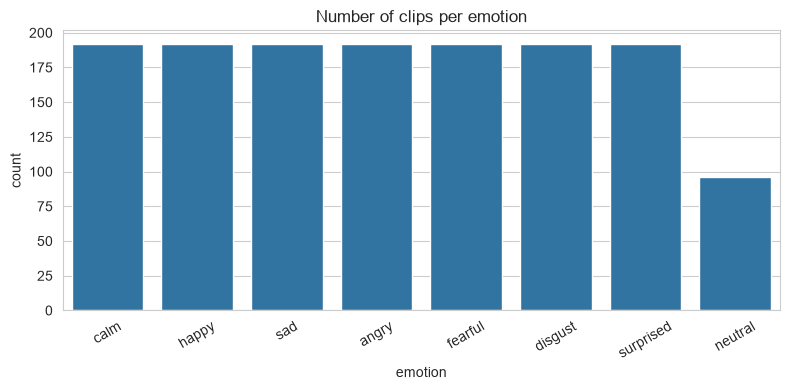

In [30]:
plt.figure(figsize=(8, 4))
sns.countplot(data=df, x="emotion", order=df["emotion"].value_counts().index)
plt.title("Number of clips per emotion")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


## Listen to a couple of samples and look at their waveform + spectrogram

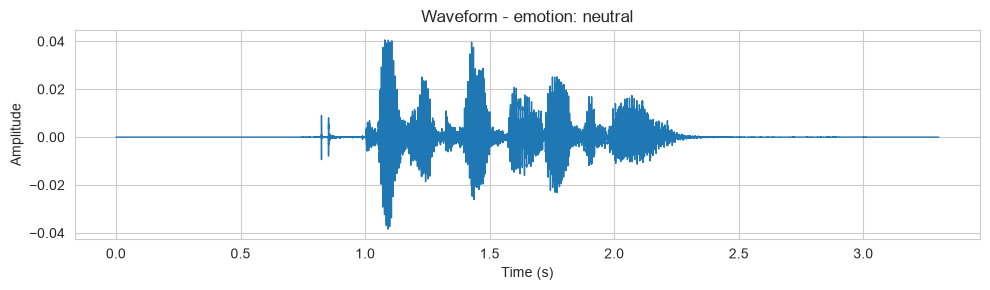

In [31]:
# Add the missing local file path column if it does not exist yet.
if "path" not in df.columns:
    df["path"] = [
        str(DATA_DIR / entry.split("Audio_Speech_Actors_01-24/", 1)[-1].lstrip("/"))
        for entry in df["zip_entry"]
    ]

sample_row = df.iloc[0]
sample_path = str(sample_row["path"])

# Read the audio with soundfile instead of librosa.load to avoid the
# missing soxr_ext DLL on Windows. This keeps the original sample rate.
try:
    y, sr = sf.read(sample_path, dtype="float32", always_2d=False)
except Exception:
    # Fall back to the remote zip archive if the local data has not been extracted yet.
    zip_entry = sample_row["zip_entry"]
    with zf.open(zip_entry, "r") as zf_file:
        y, sr = sf.read(io.BytesIO(zf_file.read()), dtype="float32", always_2d=False)

# Optional: convert stereo clips to mono for plotting and later feature extraction.
if y.ndim > 1:
    y = np.mean(y, axis=1)

plt.figure(figsize=(10, 3))
time_axis = np.linspace(0, len(y) / sr, num=len(y), endpoint=False)
plt.plot(time_axis, y, color="tab:blue", linewidth=1)
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.title(f"Waveform - emotion: {sample_row['emotion']}")
plt.tight_layout()
plt.show()


In [32]:
import os
import subprocess
import sys

# Fix the Windows numba/DLL issue before using librosa features.
if librosa is not None:
    try:
        import numba  # noqa: F401
    except Exception:
        try:
            subprocess.check_call(
                [
                    sys.executable,
                    "-m",
                    "pip",
                    "install",
                    "--upgrade",
                    "--disable-pip-version-check",
                    "numba",
                ],
                stdout=subprocess.DEVNULL,
                stderr=subprocess.DEVNULL,
            )
        except Exception:
            pass

        try:
            import numba  # noqa: F401
        except Exception:
            print("Numba is unavailable; continuing without it. librosa may still work, but some features may be slower or unavailable.")
            numba = None

    if "numba" in globals() and numba is not None:
        print("Numba import OK.")

    try:
        S = librosa.feature.melspectrogram(
            y=y,
            sr=sr,
            n_fft=2048,
            hop_length=512,
            n_mels=128,
            power=2.0,
        )
    except Exception as exc:
        os.environ["NUMBA_DISABLE_JIT"] = "1"
        try:
            import numba  # noqa: F401
            if numba is not None:
                numba.config.DISABLE_JIT = True
        except Exception:
            pass

        try:
            S = librosa.feature.melspectrogram(
                y=y,
                sr=sr,
                n_fft=2048,
                hop_length=512,
                n_mels=128,
                power=2.0,
            )
        except Exception as inner_exc:
            print(f"Mel spectrogram could not be created: {inner_exc}")
            S = None

    if S is not None:
        S_db = librosa.power_to_db(S, ref=np.max)
        plt.figure(figsize=(10, 4))
        librosa.display.specshow(S_db, sr=sr, x_axis="time", y_axis="mel")
        plt.colorbar(format="%+2.0f dB")
        plt.title("Mel Spectrogram")
        plt.tight_layout()
        plt.show()
    else:
        print("Skipping mel spectrogram because librosa could not build the feature in this environment.")
else:
    print("Skipping mel spectrogram because librosa is unavailable in this environment.")


Numba is unavailable; continuing without it. librosa may still work, but some features may be slower or unavailable.
Mel spectrogram could not be created: Numba could not be imported.
--------------------------------------------------------------------------------
If you are seeing this message and are undertaking Numba development work, you may need to rebuild Numba.
Please see the development set up guide:

https://numba.readthedocs.io/en/stable/developer/contributing.html.

--------------------------------------------------------------------------------
If you are not working on Numba development, the original error was: 'DLL load failed while importing _typeconv: The specified module could not be found.'.
For help, please visit:

https://numba.readthedocs.io/en/stable/user/faq.html#numba-could-not-be-imported

Skipping mel spectrogram because librosa could not build the feature in this environment.


## Duration check

Quick sanity check that clip lengths are fairly consistent - useful to know
before deciding whether to pad/trim audio for any sequence-based model.


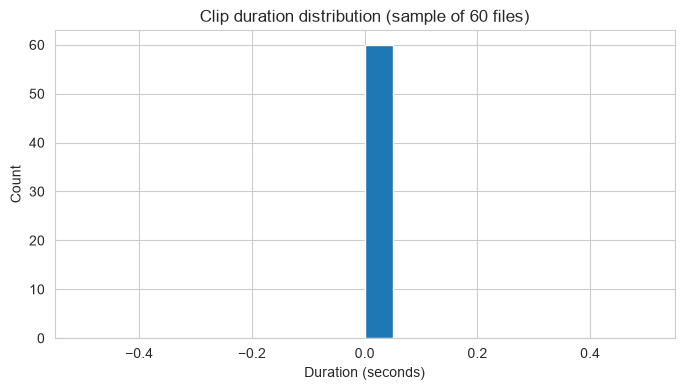

Mean duration: 0.00s, Std: 0.00s


In [41]:
if librosa is None:
    print("Skipping duration summary because librosa is unavailable in this environment.")
else:
    durations = []
    for f in df["path"].sample(min(60, len(df)), random_state=42):
        try:
            with sf.SoundFile(f) as audio:
                dur = len(audio) / audio.samplerate
        except Exception:
        # Fallback: if the file is unreadable, skip it instead of crashing
            dur = 0.0
            durations.append(dur)
        except Exception:
            # Fallback: if the file is unreadable, skip it instead of crashing
            dur = 0.0
            durations.append(dur)
            durations.append(dur)

    plt.figure(figsize=(8, 4))
    plt.hist(durations, bins=20)
    plt.xlabel("Duration (seconds)")
    plt.ylabel("Count")
    plt.title("Clip duration distribution (sample of 60 files)")
    plt.show()

    print(f"Mean duration: {np.mean(durations):.2f}s, Std: {np.std(durations):.2f}s")


## Next step

Head over to `02_feature_extraction_and_model_training.ipynb` to turn these
clips into MFCC / Chroma / Mel features and train the classifier.
